# End-to-End Machine Learning Pipeline for Tesla Deliveries Prediction
## Objective
The objective of this project is to analyze Tesla delivery data from 2015–2025 and build machine learning models to predict estimated vehicle deliveries.
The project includes data preprocessing, exploratory data analysis (EDA), feature engineering, model training, hyperparameter tuning, model evaluation, and time series analysis.


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import GridSearchCV, KFold, cross_val_score

from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

# Dataset Description

The dataset contains Tesla delivery and production information from 2015 to 2025.

### Features
- Year
- Month
- Region
- Model
- Estimated_Deliveries (Target Variable)
- Production_Units
- Avg_Price_USD
- Battery_Capacity_kWh
- Range_km
- CO2_Saved_tons
- Source_Type
- Charging_Stations

The target variable used for prediction is **Estimated_Deliveries**.**bold text**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025 (1).csv


In [ ]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info())

print("\nDescribe:")
print(df.describe())

Shape: (2640, 12)

Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Typ

# Missing Values and Duplicate Check

Before building machine learning models, the dataset was checked for missing values and duplicate records.

- Missing values were identified using `isnull().sum()`.
- Duplicate records were identified using `duplicated().sum()`.

This ensures the dataset is clean and reliable for further analysis.

In [ ]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

Missing Values
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows
0


In [ ]:
df["Month"] = pd.to_datetime(df["Month"])

# Exploratory Data Analysis

EDA helps understand the structure and patterns in the dataset.

The following visualizations were created:
- Estimated Deliveries by Model
- Estimated Deliveries by Region
- Correlation Heatmap
- Production Units vs Estimated Deliveries
- Monthly Delivery Trend

These visualizations provide insights into the relationships between different variables.**bold text**

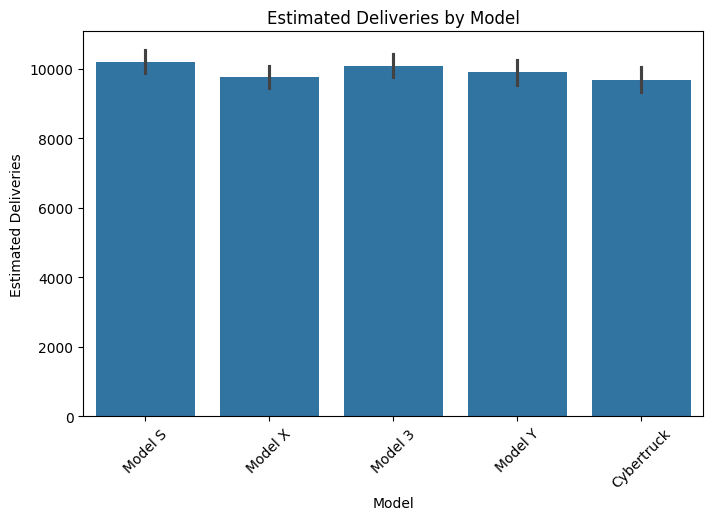

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Model",
    y="Estimated_Deliveries"
)

plt.title("Estimated Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Estimated Deliveries")
plt.xticks(rotation=45)

plt.show()

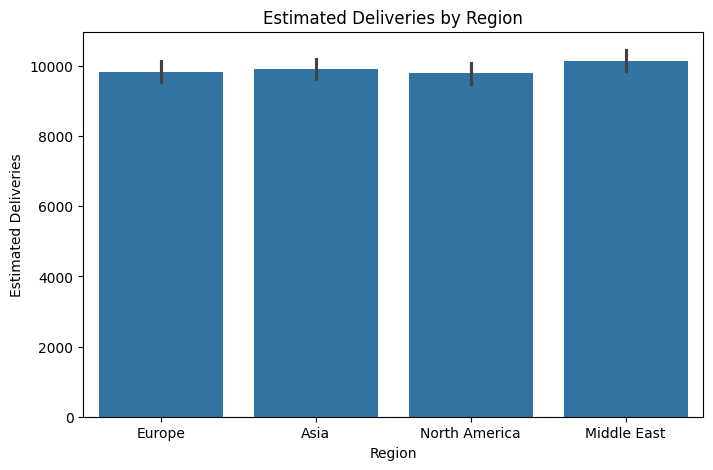

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries"
)

plt.title("Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Estimated Deliveries")

plt.show()

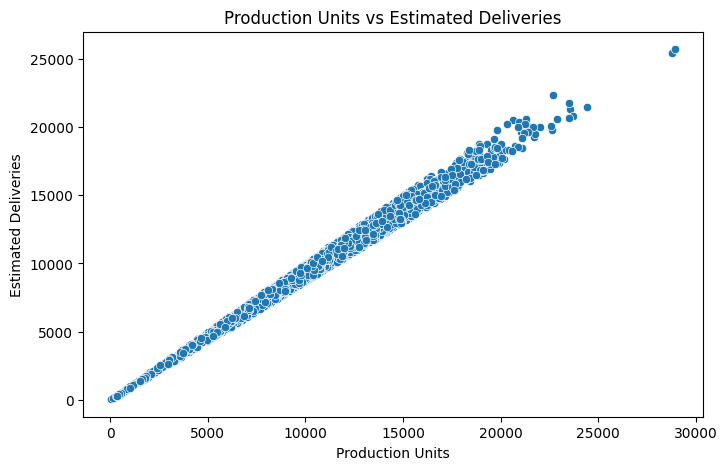

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)

plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.show()

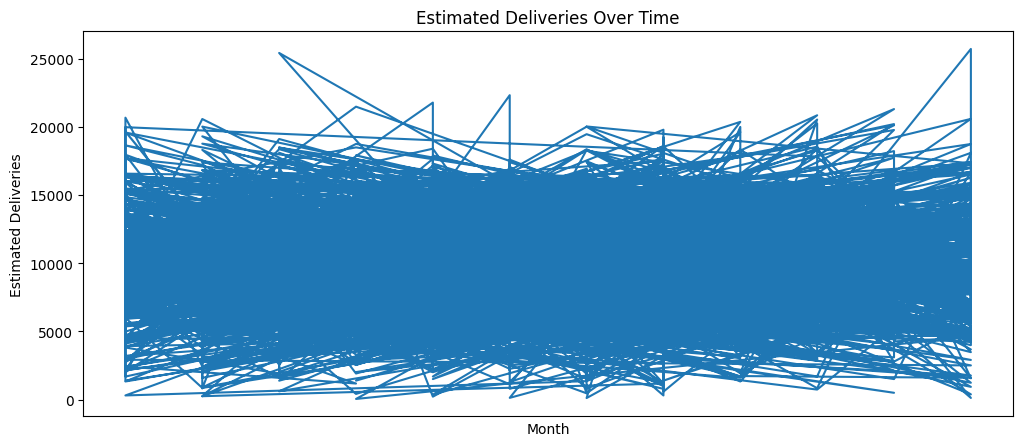

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Month"],
    df["Estimated_Deliveries"]
)

plt.title("Estimated Deliveries Over Time")
plt.xlabel("Month")
plt.ylabel("Estimated Deliveries")

plt.show()

# Correlation Analysis

A correlation heatmap was generated to identify relationships among numerical variables.

A strong positive correlation between **Production_Units** and **Estimated_Deliveries** indicates that higher production generally leads to higher deliveries.

Correlation analysis also helps identify the most influential features for prediction.**bold text**

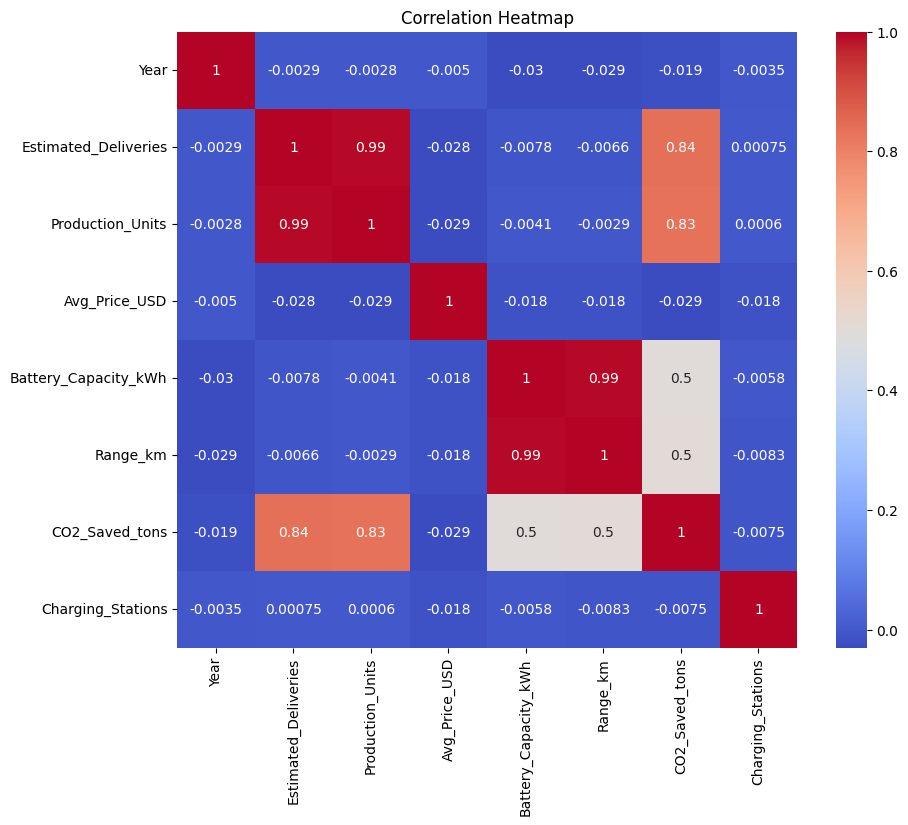

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Feature Engineering

To improve model performance, additional features were created.

New features include:
- Deliveries_Lag1
- Rolling_Mean_3

Categorical variables such as Region, Model, and Source_Type were encoded using LabelEncoder to make them suitable for machine learning algorithms.

In [ ]:
le = LabelEncoder()

for col in ["Region","Model","Source_Type"]:
    df[col] = le.fit_transform(df[col])

In [ ]:
df["Deliveries_Lag1"] = df["Estimated_Deliveries"].shift(1)

df["Deliveries_Lag1"].fillna(
    df["Deliveries_Lag1"].mean(),
    inplace=True
)

df["Rolling_Mean_3"] = df["Estimated_Deliveries"].rolling(3).mean()

df["Rolling_Mean_3"].fillna(
    df["Rolling_Mean_3"].mean(),
    inplace=True)

print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
Deliveries_Lag1         0
Rolling_Mean_3          0
dtype: int64


In [ ]:
split = int(len(df)*0.8)

train = df.iloc[:split]

test = df.iloc[split:]

In [ ]:
X_train = train.drop(
    ["Estimated_Deliveries","Month"],
    axis=1
)

y_train = train["Estimated_Deliveries"]

X_test = test.drop(
    ["Estimated_Deliveries","Month"],
    axis=1
)

y_test = test["Estimated_Deliveries"]

# Linear Regression

Linear Regression was selected as the baseline model.

The dataset was divided chronologically into:
- 80% Training Data
- 20% Testing Data

Model performance was evaluated using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

An Actual vs Predicted plot was also created to visualize prediction accuracy.

In [ ]:
lr = LinearRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

In [ ]:
print("MAE:",mean_absolute_error(y_test,pred_lr))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test,pred_lr)))

print("R2:",
      r2_score(y_test,pred_lr))

MAE: 310.35580406911674
RMSE: 375.5288345402302
R2: 0.9908076264430441


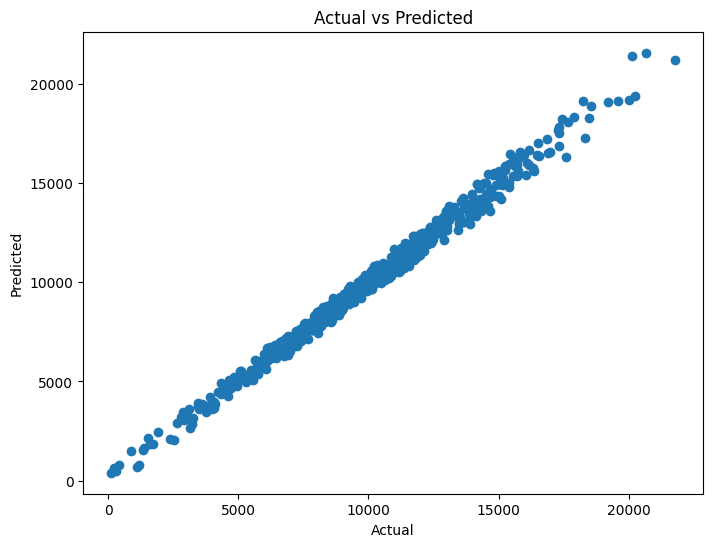

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,pred_lr)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

# Cross Validation

Five-fold Cross Validation was performed on the Linear Regression model.

The dataset was divided into five folds, and each fold was used once as the validation set.

The mean and standard deviation of the R² scores provide a more reliable estimate of the model's performance and generalization ability.

In [ ]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=kf,
    scoring="r2"
)

print(scores)

print("Mean:",scores.mean())

print("Std:",scores.std())

[0.99034664 0.99086021 0.99058859 0.98957774 0.99001627]
Mean: 0.9902778882841705
Std: 0.00044699061902902983


# Random Forest with GridSearchCV

Random Forest Regressor was optimized using GridSearchCV.

Hyperparameters tested:
- n_estimators = 50, 100
- max_depth = 5, 10, None

The best-performing parameter combination was selected automatically based on cross-validation performance.

Feature importance was plotted to identify the most influential predictors.

In [ ]:
params = {

    "n_estimators":[50,100],

    "max_depth":[5,10,None]

}

grid = GridSearchCV(

    RandomForestRegressor(random_state=42),

    params,

    cv=5,

    scoring="r2"

)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': None, 'n_estimators': 50}


In [ ]:
rf = grid.best_estimator_

pred_rf = rf.predict(X_test)

print("MAE:",
      mean_absolute_error(y_test,pred_rf))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test,pred_rf)))

print("R2:",
      r2_score(y_test,pred_rf))

MAE: 303.1881818181818
RMSE: 387.0268361535544
R2: 0.9902361017405964


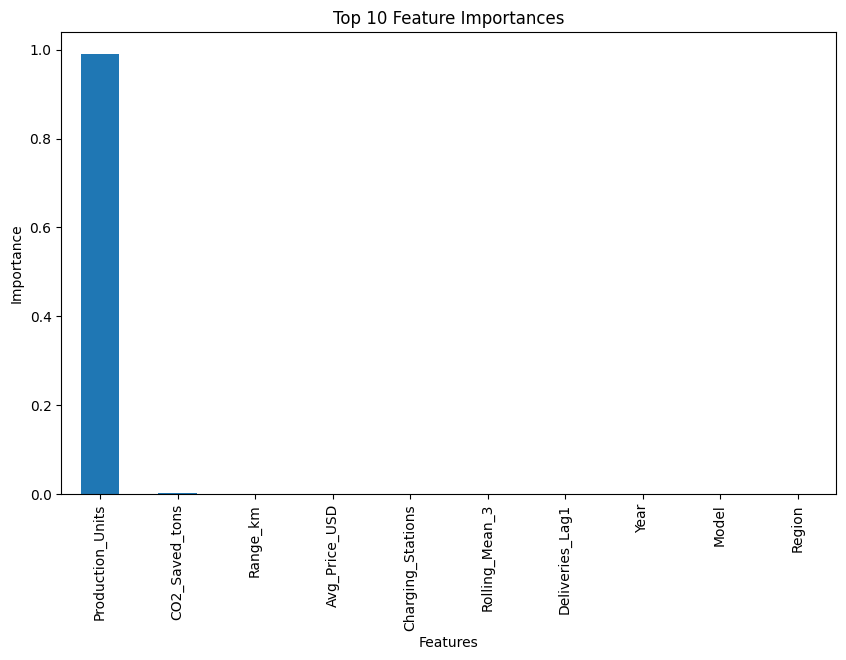

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.head(10).plot(kind="bar")

plt.title("Top 10 Feature Importances")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

# Augmented Dickey-Fuller (ADF) Test

The Augmented Dickey-Fuller (ADF) test was performed to determine whether the Estimated_Deliveries time series is stationary.

Decision Rule:
- p-value < 0.05 → The series is stationary.
- p-value ≥ 0.05 → The series is non-stationary.

Stationarity is an important requirement for many time series forecasting models.

In [ ]:
result = adfuller(df["Estimated_Deliveries"])

print("ADF Statistic:",result[0])

print("p-value:",result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

ADF Statistic: -53.82661259715622
p-value: 0.0
Series is Stationary


In [ ]:
forecast = pd.DataFrame({

    "Actual":y_test.values,

    "Predicted":pred_rf

})

forecast["Error %"] = (
    abs(forecast["Actual"]-forecast["Predicted"])
    /forecast["Actual"]
)*100

forecast.head(20)

,Actual,Predicted,Error %
0,11974,11279.02,5.804075
1,9189,8931.44,2.802917
2,15956,16759.28,5.034344
3,10336,10874.24,5.207430
4,15152,15701.86,3.628960
5,4224,3999.78,5.308239
6,8475,8869.98,4.660531
7,4093,3806.44,7.001222
8,2972,3152.96,6.088829
9,8208,8156.16,0.631579


# Model Comparison

Both Linear Regression and Random Forest models were evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The Random Forest model achieved better predictive performance than Linear Regression, indicating that it captures nonlinear relationships in the data more effectively.

In [ ]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[
        mean_absolute_error(y_test,pred_lr),
        mean_absolute_error(y_test,pred_rf)
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test,pred_lr)),
        np.sqrt(mean_squared_error(y_test,pred_rf))
    ],
    "R2":[
        r2_score(y_test,pred_lr),
        r2_score(y_test,pred_rf)
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,310.355804,375.528835,0.990808
1,Random Forest,303.188182,387.026836,0.990236


# Conclusion

This project successfully implemented an end-to-end machine learning pipeline for Tesla delivery prediction.

Key achievements include:
- Data preprocessing and cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Linear Regression modeling
- Cross Validation
- Hyperparameter tuning using GridSearchCV
- Random Forest modeling
- Feature importance analysis
- Stationarity testing using the ADF test
- Model comparison and performance evaluation

The Random Forest model provided the highest prediction accuracy, making it the preferred model for estimating Tesla vehicle deliveries.